In [ ]:
from pathlib import Path
from met_pipeline.io import load_excel, load_csv, normalize_kab_kota
from met_pipeline.quality import compute_entity_completeness

PROJECT_ROOT = Path.cwd().parent

df = load_excel(
    PROJECT_ROOT / "data" / "raw" / "Data_Timbulan_Sampah_SIPSN_KLHK.xlsx",
    header=0,
)

ref_df = load_csv(
    PROJECT_ROOT / "data" / "reference" / "master_kab_reference_final.csv"
)


In [41]:
df.columns

Index(['tahun', 'provinsi', 'kabupaten/kota', 'timbulan sampah harian(ton)',
       'timbulan sampah tahunan(ton)'],
      dtype='object')

In [42]:
ref_df.columns

Index(['provinsi', 'kab_kota'], dtype='object')

In [43]:
df["kab_kota_key"] = df["kabupaten/kota"].apply(normalize_kab_kota)
ref_df["kab_kota_key"] = ref_df["kab_kota"].apply(normalize_kab_kota)

In [44]:
merged = compute_entity_completeness(
    df=df,
    reference_df=ref_df,
    year_col="tahun",
    province_col="provinsi",
    entity_key_col="kab_kota_key",
    value_col="timbulan sampah tahunan(ton)",
)

In [45]:
merged.head()

,provinsi,kab_kota_key,tahun,timbulan sampah tahunan(ton),completeness
0,Aceh,kabupaten_aceh barat,2024,37432.21,1
1,Aceh,kabupaten_aceh barat,2023,36813.72,1
2,Aceh,kabupaten_aceh barat,2022,37021.59,1
3,Aceh,kabupaten_aceh barat,2021,NaN,0
4,Aceh,kabupaten_aceh barat,2020,NaN,0


In [46]:
merged["completeness"].value_counts()

completeness
0    1887
1    1711
Name: count, dtype: int64

In [47]:
merged.groupby("tahun")["completeness"].mean().sort_index()

tahun
2018    0.001946
2019    0.445525
2020    0.449416
2021    0.443580
2022    0.626459
2023    0.750973
2024    0.610895
Name: completeness, dtype: float64

In [48]:
merged.groupby(["tahun", "provinsi"])["completeness"].mean()

tahun  provinsi         
2018   Aceh                 0.000000
       Bali                 0.000000
       Banten               0.000000
       Bengkulu             0.000000
       DKI Jakarta          0.000000
                              ...   
2024   Sulawesi Tenggara    0.294118
       Sulawesi Utara       0.933333
       Sumatera Barat       0.736842
       Sumatera Selatan     0.529412
       Sumatera Utara       0.303030
Name: completeness, Length: 266, dtype: float64

region muncul di 2022
Kabupaten Sumba Barat Daya	25 Juli 2022
Kabupaten Sumba Tengah	5 Juli 2022

In [49]:
merged.head()

,provinsi,kab_kota_key,tahun,timbulan sampah tahunan(ton),completeness
0,Aceh,kabupaten_aceh barat,2024,37432.21,1
1,Aceh,kabupaten_aceh barat,2023,36813.72,1
2,Aceh,kabupaten_aceh barat,2022,37021.59,1
3,Aceh,kabupaten_aceh barat,2021,NaN,0
4,Aceh,kabupaten_aceh barat,2020,NaN,0


In [50]:
col = "timbulan sampah tahunan(ton)"

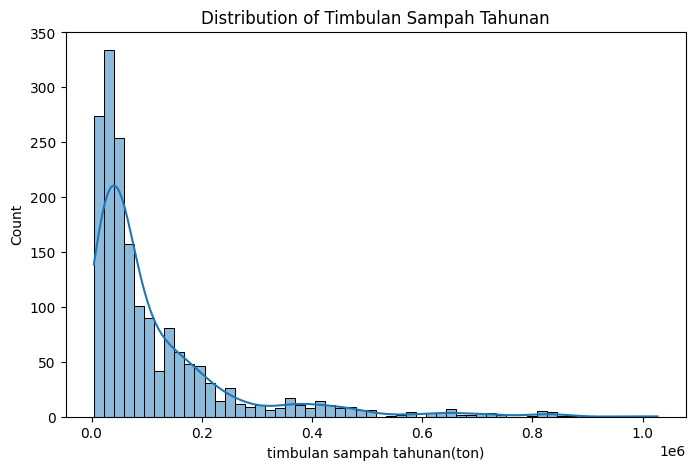

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

data = df[col].dropna()

plt.figure(figsize=(8,5))
sns.histplot(data, kde=True)
plt.title("Distribution of Timbulan Sampah Tahunan")
plt.show()

In [52]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data < lower) | (data > upper)]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(data))

Number of outliers: 156
Percentage of outliers: 0.08970672800460035


In [53]:
import pandas as pd

data = df[[col, "provinsi"]].dropna()

Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data[col] < lower) | (data[col] > upper)]

In [54]:
outlier_by_province = (
    outliers.groupby("provinsi")
    .size()
    .sort_values(ascending=False)
)

outlier_by_province

provinsi
Jawa Barat          43
DKI Jakarta         24
Jawa Tengah         22
Jawa Timur          19
Banten              15
Sumatera Utara      11
Riau                 6
Sulawesi Selatan     5
Bali                 4
Sumatera Selatan     4
Kepulauan Riau       3
dtype: int64

In [55]:
total_by_province = df.groupby("provinsi").size()

outlier_ratio = (
    outlier_by_province / total_by_province
).sort_values(ascending=False)

outlier_ratio

provinsi
DKI Jakarta                   0.827586
Jawa Barat                    0.457447
Banten                        0.441176
Riau                          0.166667
Sumatera Utara                0.166667
Jawa Tengah                   0.139241
Jawa Timur                    0.101064
Kepulauan Riau                0.090909
Bali                          0.083333
Sumatera Selatan              0.078431
Sulawesi Selatan              0.044643
Aceh                               NaN
Bengkulu                           NaN
Daerah Istimewa Yogyakarta         NaN
Gorontalo                          NaN
Jambi                              NaN
Kalimantan Barat                   NaN
Kalimantan Selatan                 NaN
Kalimantan Tengah                  NaN
Kalimantan Timur                   NaN
Kalimantan Utara                   NaN
Kepulauan Bangka Belitung          NaN
Lampung                            NaN
Maluku                             NaN
Maluku Utara                       NaN
Nusa Tenggara Ba

In [56]:
df_jabar = df[df["provinsi"] == "jawa barat"].copy()

In [57]:
X = df_jabar[["timbulan sampah tahunan(ton)"]].dropna()

In [58]:
df["provinsi"].unique()

array(['Aceh', 'Sumatera Utara', 'Sumatera Barat', 'Riau', 'Jambi',
       'Sumatera Selatan', 'Bengkulu', 'Lampung',
       'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'DKI Jakarta',
       'Jawa Barat', 'Jawa Tengah', 'Daerah Istimewa Yogyakarta',
       'Jawa Timur', 'Banten', 'Bali', 'Nusa Tenggara Barat',
       'Nusa Tenggara Timur', 'Kalimantan Barat', 'Kalimantan Tengah',
       'Kalimantan Selatan', 'Kalimantan Timur', 'Kalimantan Utara',
       'Sulawesi Utara', 'Sulawesi Tengah', 'Sulawesi Selatan',
       'Sulawesi Tenggara', 'Gorontalo', 'Sulawesi Barat', 'Maluku',
       'Maluku Utara', 'Papua', 'Papua Barat', 'Papua Selatan',
       'Papua Tengah', 'Papua Barat Daya', 'Papua Pegunungan'],
      dtype=object)

In [59]:
from sklearn.ensemble import IsolationForest

df_jabar = df[df["provinsi"] == "Jawa Barat"].copy()

X = df_jabar[["timbulan sampah tahunan(ton)"]].dropna()

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(X)

df_jabar.loc[X.index, "anomaly_flag"] = iso.predict(X)

In [60]:
df_2024 = df[df["tahun"] == 2024].copy()

In [61]:
df_jateng_2024 = df_2024[df_2024["provinsi"] == "Jawa Tengah"].copy()

In [62]:
col = "timbulan sampah tahunan(ton)"

X = df_jateng_2024[[col]].dropna()

X.shape

(26, 1)

In [63]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(X)

df_jateng_2024.loc[X.index, "anomaly_flag"] = iso.predict(X)

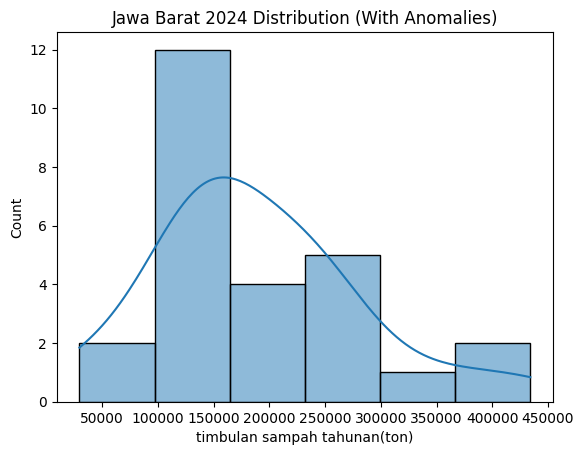

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df_jateng_2024[col], kde=True)
plt.title("Jawa Barat 2024 Distribution (With Anomalies)")
plt.show()

In [65]:
normal_data = df_jateng_2024[df_jabar_2024["anomaly_flag"] == 1][col]

plt.figure()
sns.histplot(normal_data, kde=True)
plt.title("Jawa Barat 2024 Distribution (Without Anomalies)")
plt.show()

NameError: name 'df_jabar_2024' is not defined

In [ ]:
df_2024 = df[df["tahun"] == 2024].copy()

df_2024.shape

(318, 6)

In [ ]:
col = "timbulan sampah tahunan(ton)"

X = df_2024[[col]].dropna()

X.shape

(318, 1)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.03,  # 3% anomalies
    random_state=42
)

iso.fit(X)

df_2024.loc[X.index, "anomaly_flag"] = iso.predict(X)

In [ ]:
global_anomalies = df_2024[df_2024["anomaly_flag"] == -1]

global_anomalies[
    ["provinsi", "kabupaten/kota", col]
].sort_values(col, ascending=False)

,provinsi,kabupaten/kota,timbulan sampah tahunan(ton)
178,Banten,Kota Tangerang,798405.91
87,DKI Jakarta,Kota Adm. Jakarta Selatan,725690.82
173,Jawa Timur,Kota Surabaya,660946.82
102,Jawa Barat,Kota Bekasi,645426.98
30,Sumatera Utara,Kota Medan,632149.41
96,Jawa Barat,Kab. Bekasi,614462.32
100,Jawa Barat,Kota Bandung,546151.49
86,DKI Jakarta,Kota Adm. Jakarta Utara,509694.50
103,Jawa Barat,Kota Depok,497529.02
88,Jawa Barat,Kab. Cianjur,462637.87


In [ ]:
anomaly_by_province = (
    global_anomalies.groupby("provinsi")
    .size()
    .sort_values(ascending=False)
)

anomaly_by_province

provinsi
Jawa Barat        5
DKI Jakarta       2
Banten            1
Jawa Timur        1
Sumatera Utara    1
dtype: int64

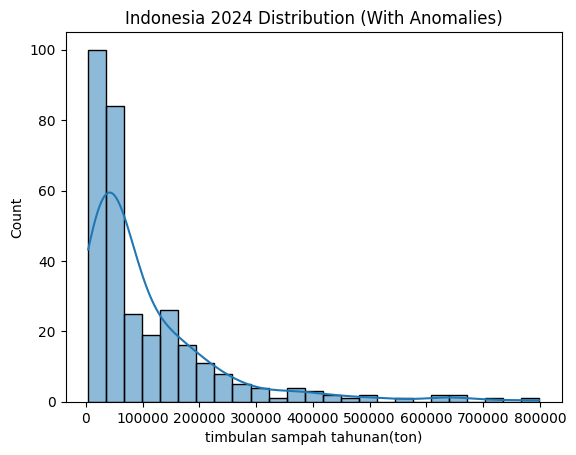

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df_2024[col], kde=True)
plt.title("Indonesia 2024 Distribution (With Anomalies)")
plt.show()

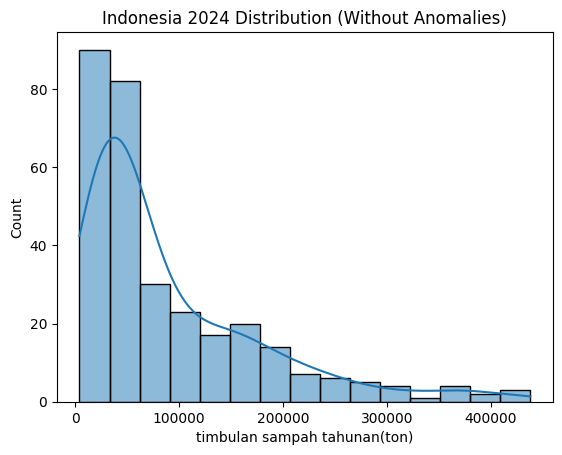

In [ ]:
normal_data = df_2024[df_2024["anomaly_flag"] == 1][col]

plt.figure()
sns.histplot(normal_data, kde=True)
plt.title("Indonesia 2024 Distribution (Without Anomalies)")
plt.show()

In [ ]:
#update
#restuktrurisasai penilaian kembali
#update restruktur.